In [1]:
!pip install -q transformers datasets
!pip install mtcnn
!pip install tensorflow
!pip install lz4

In [2]:
from datasets import load_dataset
import tensorflow as tf
from transformers import ViTImageProcessor, TFViTModel
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("tonyassi/celebrity-1000", split="train")

selected_old_ids = range(10)
print("Original label IDs used:", selected_old_ids)
print("Total images before filtering:", len(dataset))

def filter_10(example):
    return example["label"] in selected_old_ids

dataset = dataset.filter(filter_10)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Original label IDs used: range(0, 10)
Total images before filtering: 18184


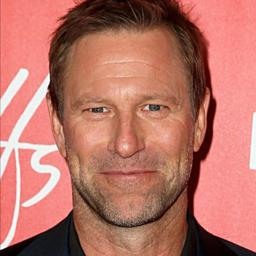

In [4]:
dataset[0]['image']

In [5]:
print(len(selected_old_ids))

10


In [6]:
dataset.shape

(160, 2)

In [7]:
from transformers import ViTImageProcessor

MODEL_NAME = "google/vit-base-patch16-224-in21k"

embedder = TFViTModel.from_pretrained(MODEL_NAME, from_pt=True)

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


In [8]:
def preprocess(batch):
    processed_image = processor(images=batch["image"], return_tensors="np")
    return {"pixel_values": processed_image["pixel_values"]}

In [9]:
dataset = dataset.map(preprocess, batched=True)

In [10]:
dataset

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 160
})

In [11]:
ds = dataset.with_format("tensorflow")
tf_ds = dataset.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    batch_size=64,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [12]:
all_embeddings = []

for batch, labels in tf_ds:
    outputs = embedder(batch)
    emb = outputs.pooler_output
    all_embeddings.append(emb)

In [13]:
all_embeddings = np.concatenate(all_embeddings,axis=0)
all_embeddings.shape

(160, 768)

In [14]:
emb_list = [emb for emb in all_embeddings]
dataset = dataset.add_column("embedding", emb_list)

In [15]:
ds=dataset.remove_columns(['pixel_values',"image"])
ds

Dataset({
    features: ['label', 'embedding'],
    num_rows: 160
})

Load & split celebrity-1000 (70/10/20)

In [16]:
dataset_shuffled = ds.shuffle(seed=42)

train_temp = dataset_shuffled.train_test_split(test_size=0.30, seed=42, stratify_by_column='label')
train_ds = train_temp["train"]
temp_ds  = train_temp["test"]

val_test = temp_ds.train_test_split(test_size=2/3, seed=42)
val_ds = val_test["train"]
test_ds = val_test["test"]

num_classes = len(selected_old_ids)

In [17]:
train_ds.shape

(112, 2)

In [18]:
x_train = np.array(train_ds["embedding"])
y_train = np.array(train_ds["label"])
x_val = np.array(val_ds["embedding"])
y_val = np.array(val_ds["label"])
x_test = np.array(test_ds["embedding"])
y_test = np.array(test_ds["label"])

In [19]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Input(shape=(768,)),
    # layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,722 (389.54 KB)

 Trainable params: 99,722 (389.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step - accuracy: 0.3560 - loss: 1.9666 - val_accuracy: 0.5000 - val_loss: 1.6132
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5884 - loss: 1.4649 - val_accuracy: 0.6875 - val_loss: 1.2624
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8024 - loss: 1.0279 - val_accuracy: 0.9375 - val_loss: 0.9858
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8720 - loss: 0.7886 - val_accuracy: 0.7500 - val_loss: 0.8307
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8814 - loss: 0.6277 - val_accuracy: 0.8125 - val_loss: 0.6636
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9024 - loss: 0.5251 - val_accuracy: 1.0000 - val_loss: 0.5781
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9379 - loss: 0.4380 - val_accuracy: 0.9375 - val_loss: 0.5206
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9408 - loss: 0.3649 - val_accuracy: 0.8750 - val_loss: 0.4778

We’ll also update the classifier label mapping:

In [23]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8125 - loss: 0.5766
Accuracy: 0.8125
